# Task 1 - ridge under partial observability
Reads saved tables from `outputs/tables` (run `python3 -m src.task1_ridge` first). No core logic lives here.

In [1]:
# Run from the notebooks/ folder or the repo root; all logic lives in src/.
import sys, pathlib
ROOT = pathlib.Path.cwd() if (pathlib.Path.cwd() / "src").exists() else pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
TABLES, FIGS = ROOT / "outputs" / "tables", ROOT / "outputs" / "figures"

## Sanity checks computed by the pipeline

In [2]:
pd.read_csv(TABLES / "task1_sanity.csv")

,check,value,passed
0,max |R2_direct - R2_identity|,5.684342e-14,True
1,|mean(R^2) - (noise^2 + b*)| (Monte Carlo),7.560279e-03,True
2,max | ||beta*||^2 - b* |,1.110223e-16,True
3,ridgeless SVD vs np.linalg.lstsq (max rel. dif...,4.401039e-15,True
4,"ridge(z=1) SVD vs dual solve (max rel. diff, r...",3.998425e-15,True


## Monte Carlo summary (mean, std, standard error)

In [3]:
summary = pd.read_csv(TABLES / "task1_summary.csv")
summary[summary.z.isin([0, 1, 10])].pivot(index="cq", columns="z", values="sharpe_paper_mean").round(4)

z,0.0,1.0,10.0
cq,,,
0.50,0.0087,0.0098,0.0093
0.75,0.0093,0.0146,0.0151
0.90,0.0093,0.0162,0.0166
0.95,0.0094,0.0157,0.0163
0.98,0.0096,0.0164,0.0168
1.02,0.0048,0.0178,0.0176
1.05,0.0093,0.0183,0.0179
1.10,0.0106,0.0185,0.0181
1.25,0.0132,0.0192,0.0192


## Where does the ridgeless estimator break down?
`beta_norm_sq` and `r2_paper` at z = 0 around c_q = 1.

In [4]:
summary[summary.z == 0][["cq", "p1", "r2_paper_mean", "r2_paper_se", "beta_norm_sq_mean", "sharpe_paper_mean"]].round(4)

,cq,p1,r2_paper_mean,r2_paper_se,beta_norm_sq_mean,sharpe_paper_mean
0,0.50,150,-1.0002,0.0233,1.2283,0.0087
11,0.75,225,-3.0175,0.0692,3.6986,0.0093
22,0.90,270,-9.0496,0.3753,11.0098,0.0093
33,0.95,285,-19.9086,1.1112,24.0473,0.0094
44,0.98,294,-48.5592,3.2112,58.3467,0.0096
55,1.02,306,-69.4299,7.2261,83.6837,0.0048
66,1.05,315,-21.8736,1.3522,26.2772,0.0093
77,1.10,330,-10.1615,0.3640,12.3632,0.0106
88,1.25,375,-3.9861,0.0999,4.8644,0.0132
99,1.50,450,-1.9809,0.0422,2.4415,0.0164


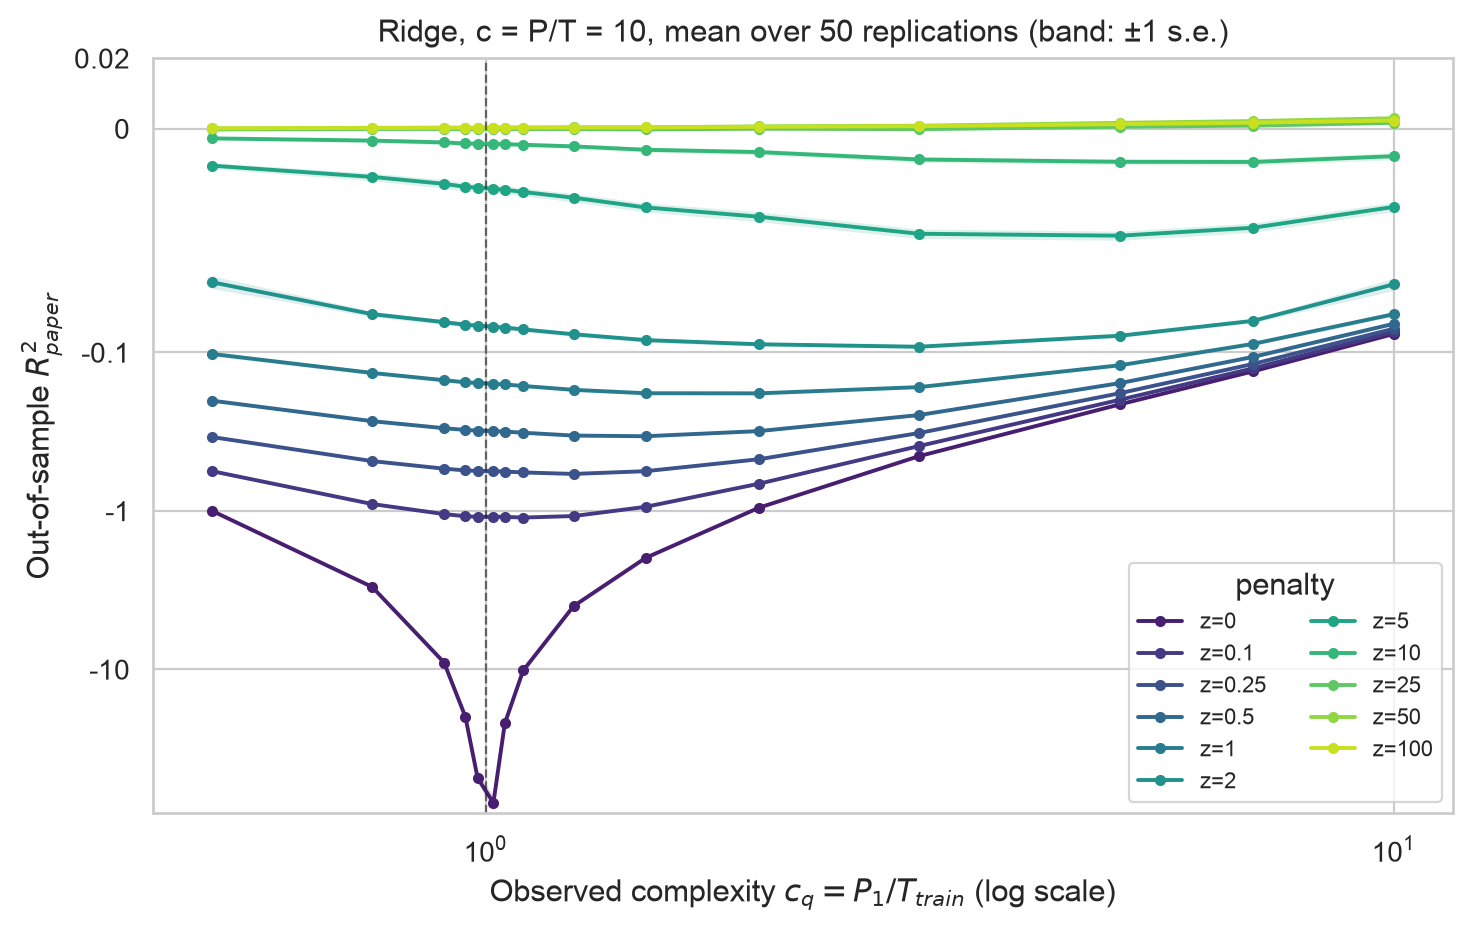

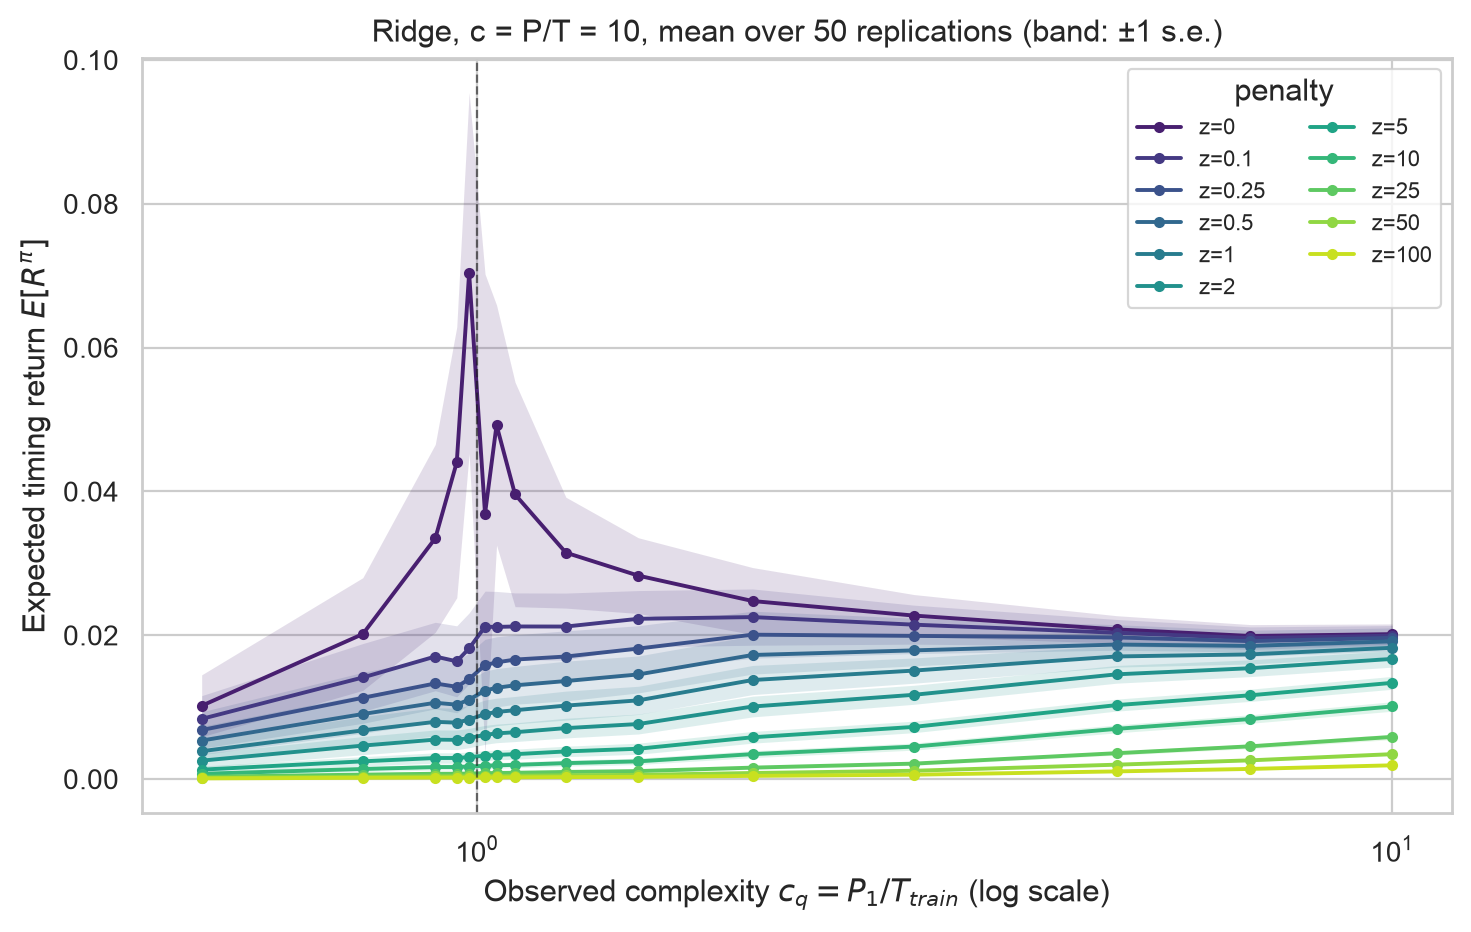

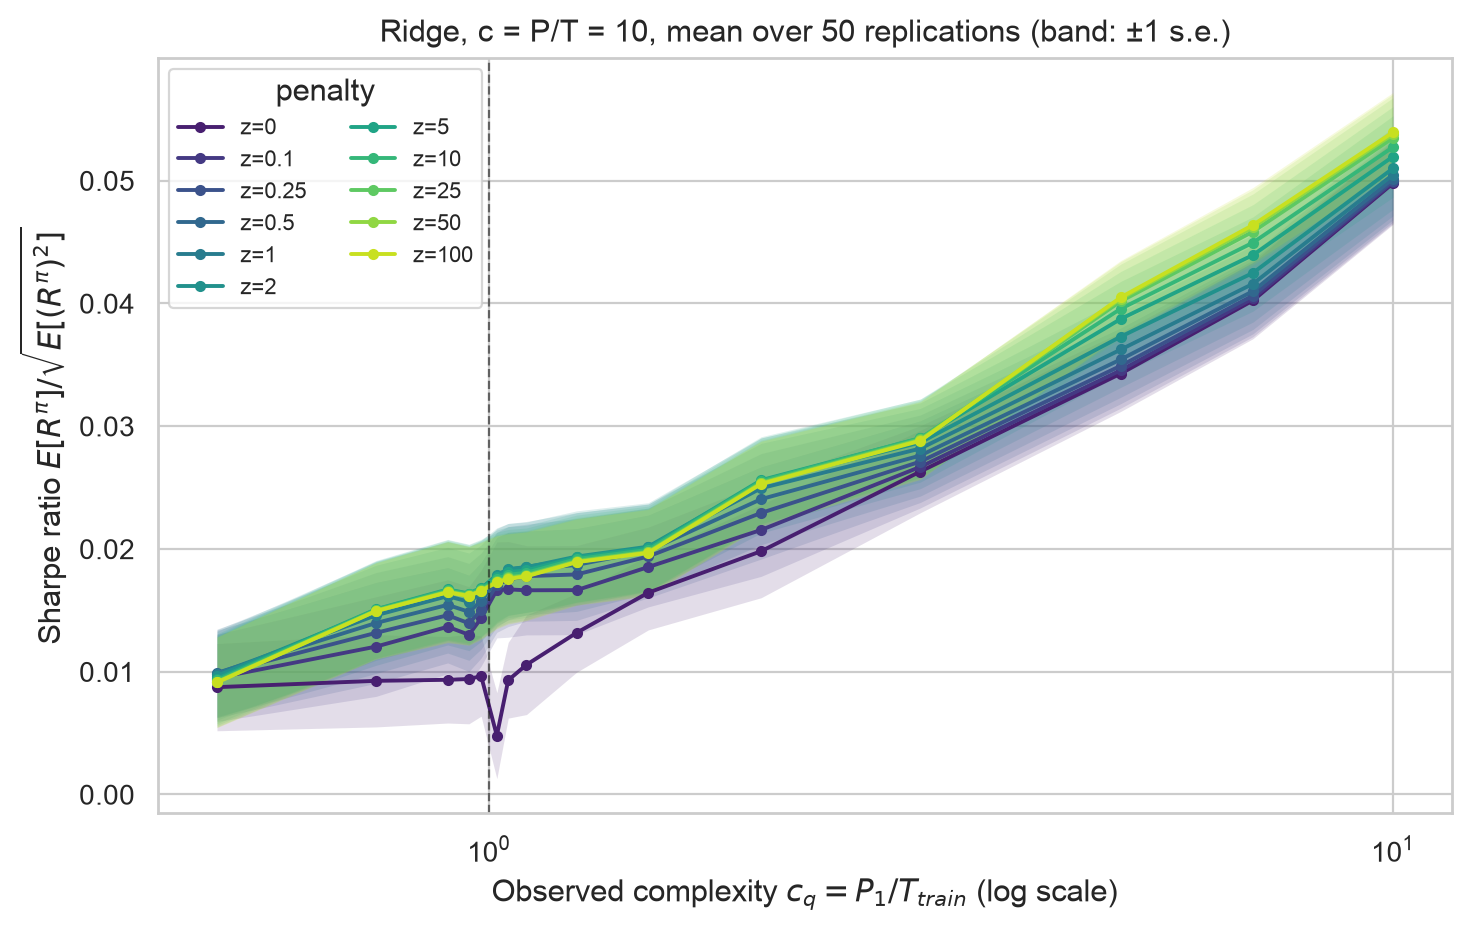

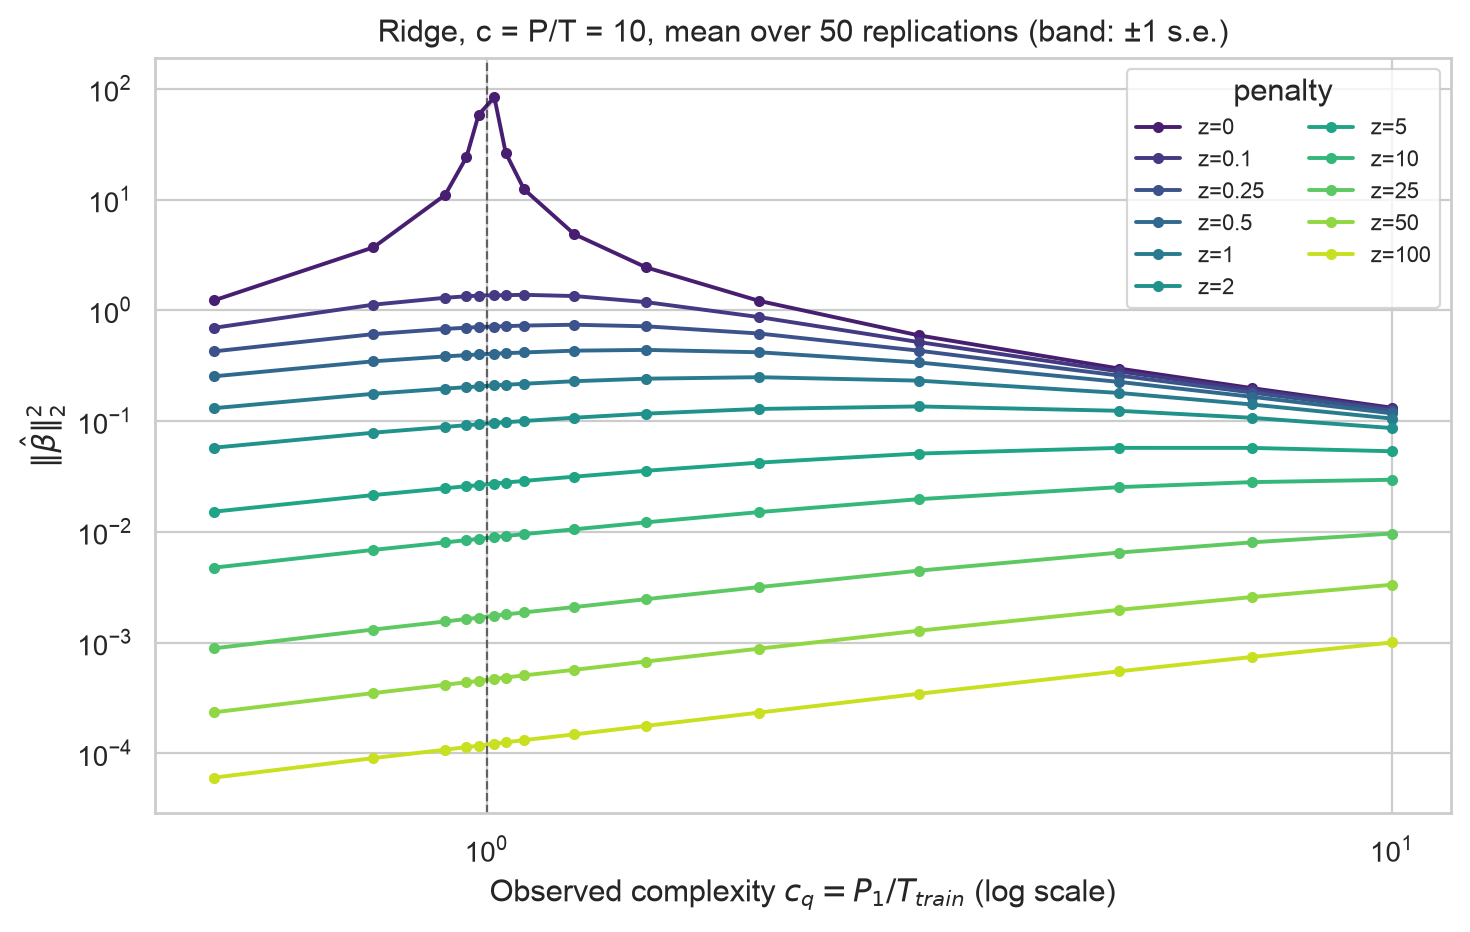

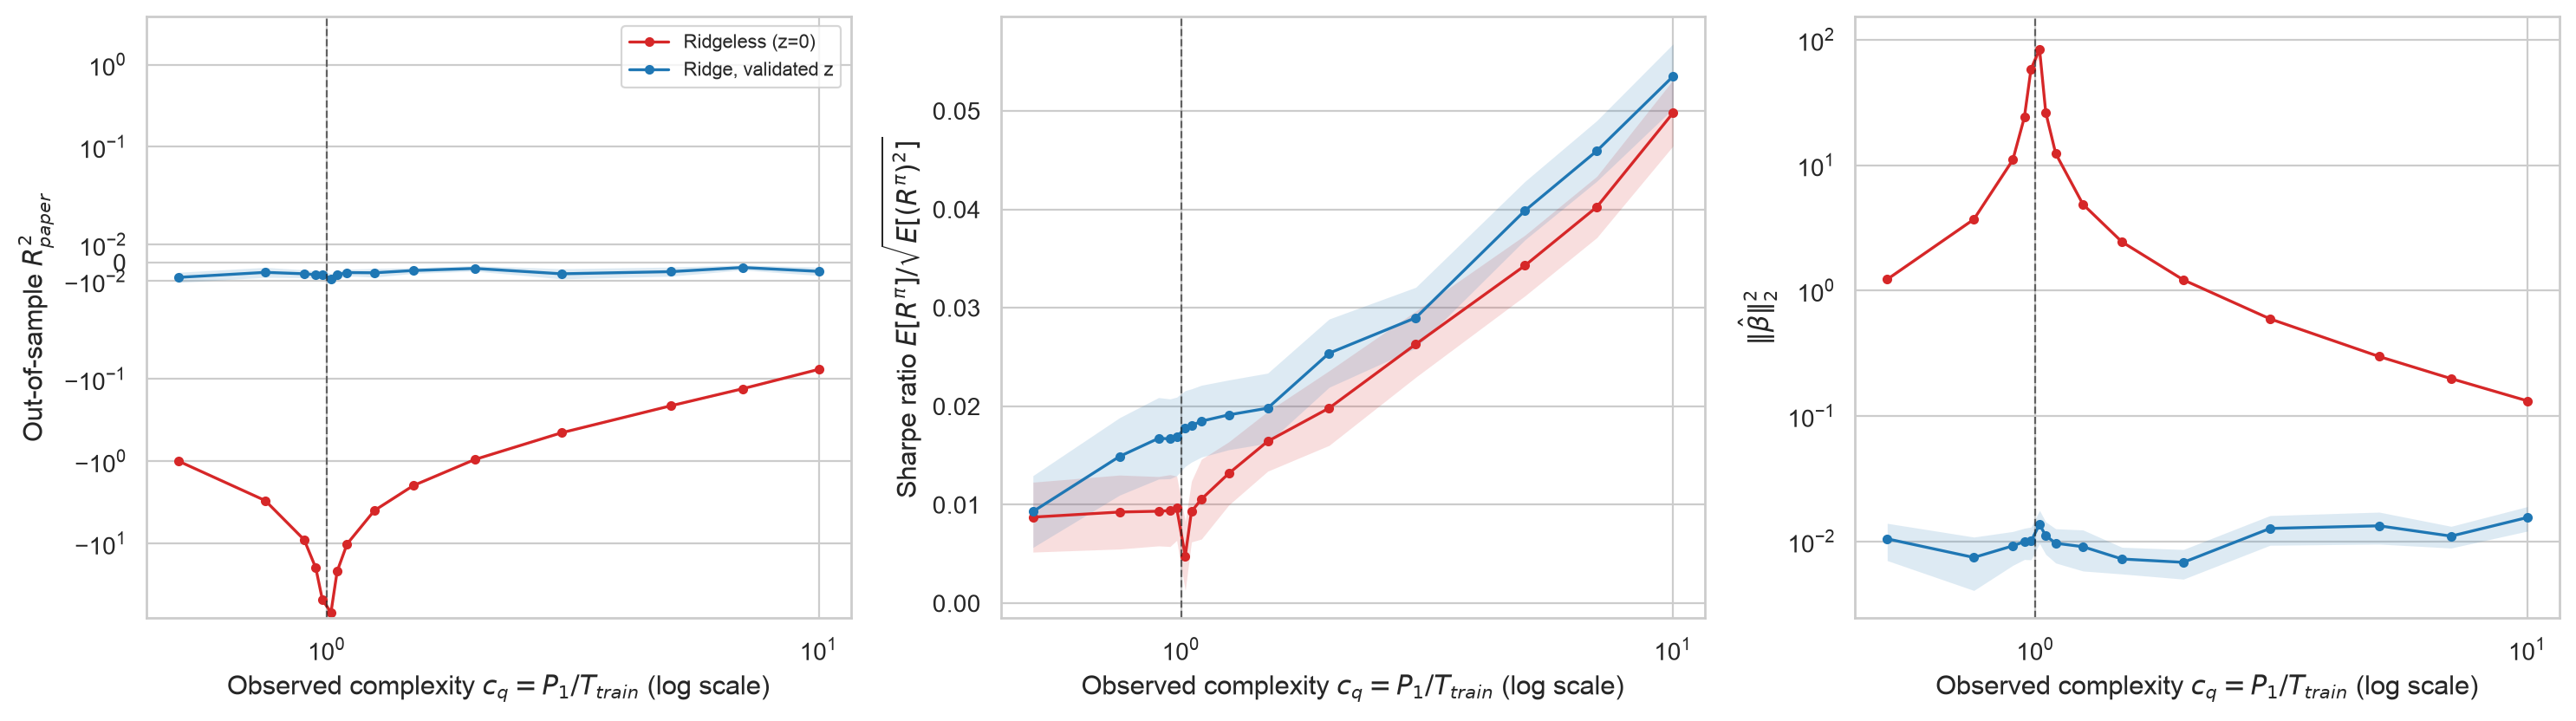

In [5]:
for f in ["task1_r2_vs_cq", "task1_timing_return_vs_cq", "task1_sharpe_vs_cq", "task1_beta_norm_vs_cq", "task1_ridgeless_vs_validated"]:
    display(Image(FIGS / f"{f}.png"))

## Re-draw a figure from the saved table with different options
`src.plotting.plot_metric_vs_cq(summary, metric, path)` is the exact function the pipeline uses.

In [6]:
from src import plotting
plotting.plot_metric_vs_cq(summary, "sharpe_var", FIGS / "task1_sharpe_var_vs_cq.png")